The purpose of this notebook is to take a csv file of all possible candidate control sources for each pulsar and calculate chi^2 and DoF values for every source, which will then allow me to sort by the chi^2 and DoF values to get the best possible control sources for each pulsar.

In [1]:
#imoprting required modules
import numpy as np
import pandas as pd

from astropy.coordinates import SkyCoord

from vasttools.query import Query

In [2]:
import logging
logging.basicConfig(level=201)

In [3]:
#calculates a weighted mean flux density for a single source
def weighted_mean_flux_density(source_df):
    sum_1overvariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            oneOverVariance = 1 / source_df['rms_image'].iloc[i]
            sum_1overvariance += (oneOverVariance ** 2)
    sumSovervariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] **2
            sumSovervariance += (S/var)
    if (sum_1overvariance == 0):
        return np.nan
    return sumSovervariance / sum_1overvariance       

In [4]:
#calculates chi_squared for a single source
def chi_squared(source_df):
    n_epochs = 0
    S_weighted = weighted_mean_flux_density(source_df)
    if (S_weighted == np.nan):
        return np.nan
    temp = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] ** 2
            num = (S - S_weighted)**2
            temp += num / var
            n_epochs += 1
    return (temp, n_epochs)

In [5]:
# make a query, and calculate a chi squared for the source found
def query_to_chi2(measurements_row):
    my_skycoord = SkyCoord(str(measurements_row.loc['ra_deg_cont']) + " " + str(measurements_row.loc['dec_deg_cont']), unit='deg')
    my_query = Query(coords=my_skycoord, epochs='all-vast', use_tiles=True, corrected_data=False)
    my_query.find_sources()
    print("        " + "0")
    return chi_squared(my_query.results[0].measurements[my_query.results[0].measurements['freq']==887.5])

In [6]:
# using query_to_chi2, calculate and input a chi2 and nu_detections value into a given source dataframe
def intelligent_chi2_from_rowdf(row_df):
    counter = 0
    for i in row_df.index.values:
        print("    " + str(i))
        row_df.loc[i, ['chi_squared', 'num_detections']] =  query_to_chi2(row_df.loc[i])
        if ((row_df.loc[i, 'chi_squared'] < 30)&(row_df.loc[i, 'num_detections'] > 20)):
            counter = counter + 1
        if (counter == 3):
            return "Completed"
    return "Completed"

In [7]:
psr_df = pd.read_csv('paper_df_VASTcoverage.csv')

In [8]:
psr_df.drop(columns=psr_df.columns[0], inplace=True)

In [9]:
psr_df.insert(8, 'control_chi_squared', np.nan)

In [10]:
psr_df

,DOF,p_value,reduced_chi_squared,reduced_chi_squared_err,modulation,modulation_err,chi_squared,chi_squared_err,control_chi_squared,GB,S1400,DM,P0,P1,AGE,DECJD,ASSOC,JNAME,RAJD
0,40,0.000000,2671.566747,16.485002,6.962338,0.076679,106862.669861,659.400073,NaN,-0.194956,300.000,478.660,0.455078,2.008920e-14,3.589132e+05,-45.986031,NaN,J1644-4559,251.205304
1,12,0.000000,4632.351515,41.018698,28.939939,2.325090,55588.218175,492.224381,NaN,-0.961032,47.800,50.372,0.562558,8.129130e-15,1.096450e+06,-28.110361,NaN,J1752-2806,268.244540
2,41,0.000000,540.357654,7.347649,14.884816,0.456145,22154.663796,301.253620,NaN,-1.018678,20.000,180.440,0.106769,1.510247e-14,1.120117e+05,-49.218056,GRS,J0908-4913,137.147750
3,40,0.000000,494.386849,7.117671,46.119800,3.369295,19775.473949,284.706823,NaN,1.944153,6.800,24.820,1.368882,1.428802e-15,1.517959e+07,-53.572128,NaN,J1534-5334,233.534492
4,47,0.000000,370.368514,5.675784,24.347607,0.891826,17407.320158,266.761857,NaN,-0.963350,21.000,88.373,0.367434,1.067181e-14,5.455155e+05,-30.673028,NaN,J1745-3040,266.484650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,5,0.966433,0.190167,0.421435,7.950592,20.337828,0.950836,2.107176,NaN,-4.871415,0.486,114.544,0.005471,6.209000e-21,1.396167e+10,-14.803503,NaN,J1843-1448,280.755729
127,2,0.660059,0.415426,1.055227,11.449910,45.571292,0.830851,2.110454,NaN,3.371841,0.340,113.803,0.006284,1.900000e-20,5.240469e+09,-49.630484,NaN,J1552-4937,238.055295
128,3,0.898704,0.196686,0.566452,8.306860,19.097985,0.590059,1.699355,NaN,2.431279,0.550,354.800,1.213381,5.986000e-15,3.211638e+06,-59.416917,NaN,J1355-5925,208.996292
129,4,0.968111,0.138320,0.407575,7.085693,28.002911,0.553278,1.630299,NaN,-4.895562,0.320,250.000,1.254052,5.960326e-15,3.333584e+06,-63.138750,NaN,J1519-6308,229.789833


In [32]:
#this will get a giant dataframe of ALL candidate control sources for ALL psrs
#I don't actually run this cell as part of this notebook, but I am including it to give an idea of how I create the list of candidate control sources
cand_controls = []
names = []
for i in psr_df.index.values:
    print(i) #debugging purposes
    query_coord = SkyCoord(str(psr_df.loc[i]['RAJD']) + " " + str(psr_df.loc[i]['DECJD']), unit='deg')
    new_query = Query(coords=query_coord, epochs='23', crossmatch_radius=3600., search_around_coordinates=True, use_tiles=True, corrected_data=False)
    new_query.find_sources()
    new_results = new_query.results[(new_query.results['flux_peak']>5)&(new_query.results['distance']>15)]
    new_results = new_results.reset_index()
    for j in np.arange(new_results.shape[0]):
        if not (new_results.loc[j]['flux_int'] < (1.5 * new_results.loc[j]['flux_peak'])):
            new_results.drop(j, inplace=True)
    new_results1 = new_results.sort_values('distance').reset_index(drop=True)
    cand_controls.append(new_results1)
    names.append(psr_df.loc[i]["JNAME"])

cand_controls_df = pd.concat(cand_controls, keys=names) #adds a multiindex based on the corresponding pulsar name for each candidate
cand_controls_df.to_csv('test2cand_controls_postprocessed.csv')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31


In [10]:
#read in your csv file of potential control sources
cands_df = pd.read_csv('all_cand_controls_truncated.csv', index_col=[2,3])

In [11]:
cands_df.drop(columns=cands_df.columns[:2], inplace=True)

In [12]:
lists=[]
for name in cands_df.index.levels[0].values:
    lists.append(cands_df.loc[name])

In [13]:
#creating a series where each series element is a dataframe of candidate control sources for each pulsar
#this is done to more easily iterate through each set of candidate controls
temp_series = pd.Series(lists)

In [14]:
#inserting a placeholder columns for chi2 and DoF 
for i in temp_series.index:
    temp_series[i].insert(0, 'chi_squared', np.nan)
    temp_series[i].insert(0, 'num_detections', np.nan)

In [15]:
for i in temp_series.index:
    temp_series[i].reset_index(inplace=True)

In [16]:
#run if using intermediates
for i in temp_series.index.values:
    temp_series[i] = pd.read_csv('intermediates/' + str(i) + '.csv')

In [18]:
for i in temp_series.index.values[106:]:
    print(i)
    intelligent_chi2_from_rowdf(temp_series[i])

106
    0
        0
    1
        0
    2
        0
    3
        0
    4
        0
    5
        0
    6
        0
    7
        0
    8
        0
    9
        0
    10
        0
    11
        0
    12
        0
107
    0
        0
    1
        0
    2
        0
    3
        0
    4
        0
    5
        0
    6
        0
    7
        0
    8
        0
    9
        0
108
    0
        0
    1
        0
    2
        0
    3
        0
    4
        0
    5
        0
    6
        0
    7
        0
    8
        0
    9
        0
    5
        0
    6
        0
    7
        0
    8
        0
111
    0
        0
    1
        0
    2
        0
    3
        0
112
    0
        0
    1
        0
    2
        0
    3
        0
    4
        0
    5
        0
    6
        0
113
    0
        0
    1
        0
    2
        0
    3
        0
    4
        0
    5
        0
    6
        0
    7
        0
114
    0
        0
    1
        0
    2
        0
    3
        0
    4
   

In [19]:
for i in temp_series.index.values[#:#]:
    temp_series[i].to_csv('intermediates/' + str(i) + '.csv')

In [10]:
import concurrent.futures

In [14]:
#calculating values and filling the placeholder columns.
#this cell uses multiprocessing to execute faster
with concurrent.futures.ThreadPoolExecutor() as executor:
    m = executor.map(intelligent_chi2_from_rowdf, temp_series)
    list(m) #need this part to make sure the thing actually executes. Look up "lazy evaluation" for more info 

Removing source_171134.2-341626.3: Epoch 5x due to missing files
Removing source_171134.2-341626.3: Epoch 6x due to missing files
Removing source_171134.2-341626.3: Epoch 8 due to missing files
Removing source_173120.5-335325.0: Epoch 5x due to missing files
Removing source_173120.5-335325.0: Epoch 6x due to missing files
Removing source_173120.5-335325.0: Epoch 8 due to missing files
Removing source_173120.5-335325.0: Epoch 20 due to missing files
Removing source_173120.5-335325.0: Epoch 21 due to missing files
Removing source_175309.1-192103.8: Epoch 20 due to missing files
Removing source_175309.1-192103.8: Epoch 21 due to missing files
Removing source_175143.6-302246.1: Epoch 13 due to missing files
Removing source_175143.6-302246.1: Epoch 20 due to missing files
Removing source_175143.6-302246.1: Epoch 21 due to missing files
Removing source_170754.7-351036.0: Epoch 5x due to missing files
Removing source_170754.7-351036.0: Epoch 6x due to missing files
Removing source_170754.7-35

KeyboardInterrupt: 

In [19]:
#sorting by chi2
for i in np.arange(temp_series.size):
    temp_series[i].sort_values('chi_squared', inplace=True)

In [23]:
#exporting each dataframe to a csv file named after its associated pulsar
psrs = cands_df.index.levels[0]
for i in np.arange(temp_series.size):
    temp_series[i].to_csv('controls_stats_bypsr_postprocessed/' + psrs[i] + '_controls_postprocessed.csv')

In [20]:
#creating a new iterable 'thing_list' which removes all candidate control sources that have a low number of detections
thing_list = []
for i in np.arange(temp_series.size):
    labels = temp_series[i][temp_series[i]['num_detections']<20].index.values
    thing = temp_series[i].drop(labels)
    thing_list.append(thing)
    print(thing.shape[0]) #this print statement is included to help verify that no pulsars have zero control sources with >20 detections, and will have empty dataframes as a result

1
5
3
7
5
12
8
5
10
10
5
10
14
8
7
6
6
7
9
8
14
10
4
3
6
6
12
4
7
6
5
1
3
7
7
8
7
9
3
14
7
8
16
3
2
7
3
13
13
7
9
2
7
6
5
4
8
7
5
3
7
2
5
9
7
2
4
6
11
7
7
2
11
4
5
6
11
6
2
4
5
3
6
11
6
5
6
5
4
5
7
1
7
9
8
2
4
11
11
8
4
8
5
6
9
17
13
10
14
5
9
4
7
8
6
15
2
8
8
6
5
3
7
8
8
11
9
4
5
4


In [21]:
#creating a comprehensive list of ALL the 'final candidates'
full_final_cands_list = []
psr_list = []
for i in np.arange(len(thing_list)):
    for j in thing_list[i].index.values:
        psr_list.append(i)
        full_final_cands_list.append(thing_list[i].loc[j])

In [22]:
full_final_cands_df = pd.DataFrame(full_final_cands_list)

In [23]:
#adding a placeholder column which will be filled with the pulsar partners for each control source
full_final_cands_df.insert(0, 'PSR_assoc', None)

In [24]:
full_final_cands_df.reset_index(inplace=True)

In [34]:
psr_list

[0,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 10,
 10,
 10,
 10,
 10,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 15,
 15,
 15,
 15,
 15,
 15,
 16,
 16,
 16,
 16,
 16,
 16,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 22,
 22,
 22,
 22,
 23,
 23,
 23,
 24,
 24,
 24,
 24,
 24,
 24,
 25,
 25,
 25,
 25,
 25,
 25,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 27,
 27,
 27,
 27,
 28,
 28,
 28,
 28,
 28,
 28,
 28,
 29,
 

In [35]:
#filling the placeholder column
for i in full_final_cands_df.index.values:
    full_final_cands_df.loc[i, 'PSR_assoc'] = cands_df.index.levels[0].values[psr_list[i]]

In [37]:
full_final_cands_df

,index,PSR_assoc,Unnamed: 0,Unnamed: 1,num_detections,chi_squared,name,ra,dec,skycoord,...,spectral_index_err,spectral_curvature_err,rms_image,has_siblings,fit_is_estimate,spectral_index_from_TT,flag_c4,comment,detection,distance
0,0,J0905-4536,0,0,32.0,35.790533,source_090523.9-453653.0,136.349583,-45.614722,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.3...",...,0.0,0.0,0.232,0.0,0.0,1.0,0.0,NaN,True,620.748006
1,2,J0907-5157,2,0,40.0,130.487065,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",...,0.0,0.0,0.185,1.0,0.0,1.0,0.0,NaN,True,631.971247
2,4,J0907-5157,4,0,38.0,308.870580,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",...,0.0,0.0,0.197,0.0,0.0,1.0,0.0,NaN,True,808.394052
3,1,J0907-5157,1,0,37.0,475.788843,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",...,0.0,0.0,0.185,1.0,0.0,1.0,0.0,NaN,True,652.517871
4,0,J0907-5157,0,0,38.0,668.070827,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",...,0.0,0.0,0.200,0.0,0.0,1.0,0.0,NaN,True,234.404365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,0,J1843-1113,0,0,49.0,54340.163286,source_184341.3-111331.1,280.921925,-11.225297,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.9...",...,0.0,0.0,0.352,0.0,0.0,1.0,0.0,NaN,True,740.204465
883,3,J1843-1448,3,0,48.0,52.838141,source_184301.4-144812.6,280.755729,-14.803503,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.7...",...,0.0,0.0,0.237,0.0,0.0,1.0,0.0,NaN,True,701.427523
884,1,J1843-1448,1,0,49.0,108.006359,source_184301.4-144812.6,280.755729,-14.803503,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.7...",...,0.0,0.0,0.256,0.0,0.0,1.0,0.0,NaN,True,942.298338
885,2,J1843-1448,2,0,49.0,146.176469,source_184301.4-144812.6,280.755729,-14.803503,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.7...",...,0.0,0.0,0.301,0.0,0.0,1.0,0.0,NaN,True,806.305386


In [38]:
#exporting to a csv file
full_final_cands_df.to_csv('all_final_controls.csv')

In [39]:
#creating csv of chi2 of the two lowest variability control sources for each pulsar. Useful for plotting purposes
chi_squareds = []
for i in np.arange(len(thing_list)):
    print(i)
    if (thing_list[i]['chi_squared'].size > 0):
        chi_squareds.append(thing_list[i]['chi_squared'].iloc[0])
    ##if (thing_list[i]['chi_squared'].size > 1):
    ##    chi_squareds.append(thing_list[i]['chi_squared'].iloc[1])
##pd.Series(chi_squareds).to_csv('test_control_chi_squareds.csv')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129


In [41]:
thing_list[1]

,Unnamed: 0,Unnamed: 1,num_detections,chi_squared,name,ra,dec,skycoord,stokes,fields,...,spectral_index_err,spectral_curvature_err,rms_image,has_siblings,fit_is_estimate,spectral_index_from_TT,flag_c4,comment,detection,distance
2,2,0,40.0,130.487065,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",I,['VAST_0913-50'],...,0.0,0.0,0.185,1.0,0.0,1.0,0.0,NaN,True,631.971247
4,4,0,38.0,308.870580,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",I,['VAST_0913-50'],...,0.0,0.0,0.197,0.0,0.0,1.0,0.0,NaN,True,808.394052
1,1,0,37.0,475.788843,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",I,['VAST_0913-50'],...,0.0,0.0,0.185,1.0,0.0,1.0,0.0,NaN,True,652.517871
0,0,0,38.0,668.070827,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",I,['VAST_0913-50'],...,0.0,0.0,0.200,0.0,0.0,1.0,0.0,NaN,True,234.404365
3,3,0,39.0,2206.199794,source_090715.9-515759.4,136.816254,-51.966489,"<SkyCoord (ICRS): (ra, dec) in deg\n (136.8...",I,['VAST_0913-50'],...,0.0,0.0,0.193,0.0,0.0,1.0,0.0,NaN,True,2.802417


In [43]:
reduced_chi_squareds = []
for i in np.arange(len(thing_list)):
    if (thing_list[i]['chi_squared'].size > 0):
        reduced_chi_squareds.append((thing_list[i]['chi_squared'].iloc[0] / (thing_list[i]['num_detections'].iloc[0] - 1)))
    ##if (thing_list[i]['chi_squared'].size > 1):
    ##    chi_squareds.append(thing_list[i]['chi_squared'].iloc[1])
##pd.Series(chi_squareds).to_csv('test_control_chi_squareds.csv')

In [69]:
psr = 'J1840-1207'
full_final_cands_df[
    full_final_cands_df['PSR_assoc']==psr
]

,index,PSR_assoc,Unnamed: 0,Unnamed: 1,num_detections,chi_squared,name,ra,dec,skycoord,...,spectral_index_err,spectral_curvature_err,rms_image,has_siblings,fit_is_estimate,spectral_index_from_TT,flag_c4,comment,detection,distance
874,1,J1840-1207,1,0,48.0,113.365822,source_184053.8-120732.6,280.224092,-12.125722,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.2...",...,0.0,0.0,0.249,0.0,0.0,1.0,0.0,NaN,True,711.251179
875,3,J1840-1207,3,0,47.0,143.106999,source_184053.8-120732.6,280.224092,-12.125722,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.2...",...,0.0,0.0,0.244,1.0,0.0,1.0,0.0,NaN,True,824.432710
876,0,J1840-1207,0,0,49.0,678.607813,source_184053.8-120732.6,280.224092,-12.125722,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.2...",...,0.0,0.0,0.253,0.0,0.0,1.0,0.0,NaN,True,150.945320
877,2,J1840-1207,2,0,49.0,926.242449,source_184053.8-120732.6,280.224092,-12.125722,"<SkyCoord (ICRS): (ra, dec) in deg\n (280.2...",...,0.0,0.0,0.264,0.0,0.0,1.0,1.0,NaN,True,763.132912


In [62]:
j = 0
for chi in chi_squareds:
    if chi > 100:
        print(cands_df.index.levels[0][j])
    j = j+1

J0907-5157
J0908-4913
J0955-5304
J1544-5308
J1733-3716
J1808-1020
J1813-2621
J1840-1207


In [68]:
k = 0
for r_chi in reduced_chi_squareds:
    if (r_chi > 2.1)&(r_chi<2.5):
        print(cands_df.index.levels[0][k])
    k = k+1

J1042-5521
J1622-4802
J1840-1207


In [ ]:
#reading this csv to a variable
chi_squareds = pd.read_csv('control_chi_squareds.csv')

In [ ]:
chi_squareds = list(chi_squareds['0'])

In [39]:
for i in chi_squareds:
    if i > 200:
        chi_squareds.remove(i)

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Control Chi^2 Histogram')

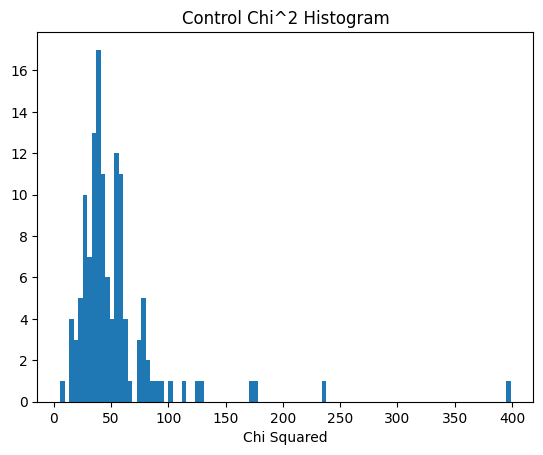

In [46]:
plt.hist(chi_squareds, bins=100)
plt.xlabel('Chi Squared')
plt.title('Control Chi^2 Histogram')

Text(0.5, 1.0, 'Control Reduced Chi^2 Histogram')

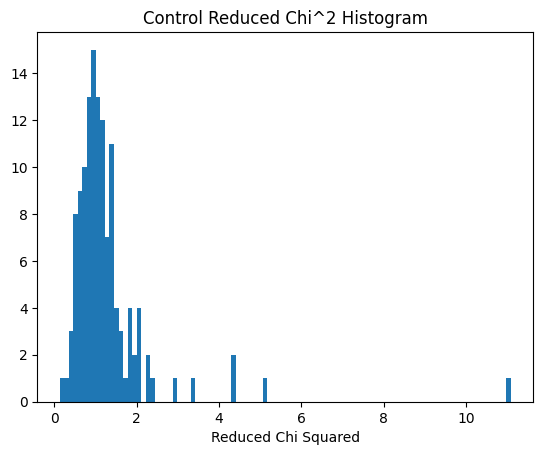

In [47]:
plt.hist(reduced_chi_squareds, bins=100)
plt.xlabel('Reduced Chi Squared')
plt.title('Control Reduced Chi^2 Histogram')

In [31]:
#creating a list of the 'final candidates': the two least variable control sources for each pulsar
final_cands_list = []
psr_list = []
for i in np.arange(len(thing_list)):
    if (thing_list[i]['chi_squared'].size > 0):
        psr_list.append(i)
        final_cands_list.append(thing_list[i].iloc[0])
    if (thing_list[i]['chi_squared'].size > 1):
        psr_list.append(i)
        final_cands_list.append(thing_list[i].iloc[1])

In [32]:
final_cands_df = pd.DataFrame(final_cands_list)

In [33]:
#adding a placeholder column which will be filled with the pulsar partners for each control source
final_cands_df.insert(0, 'PSR_assoc', None)

In [34]:
final_cands_df.reset_index(inplace=True)

In [35]:
#filling the placeholder column
for i in final_cands_df.index.values:
    final_cands_df.loc[i, 'PSR_assoc'] = cands_df.index.levels[0].values[psr_list[i]]

In [36]:
#exporting to a csv file
final_cands_df.to_csv('final_controls_postprocessed.csv')

In [22]:
final_cands_df.loc[10]

level_0                           129
PSR_assoc                  J1722-3207
num_detections                   38.0
chi_squared                101.014222
index                               1
                             ...     
spectral_index_from_TT              1
flag_c4                             0
comment                           NaN
detection                        True
distance                  2328.055292
Name: 10, Length: 61, dtype: object

In [24]:
final_cands_df[final_cands_df['PSR_assoc']=='J1722-3207']

,level_0,PSR_assoc,num_detections,chi_squared,index,name,ra,dec,skycoord,stokes,...,spectral_index_err,spectral_curvature_err,rms_image,has_siblings,fit_is_estimate,spectral_index_from_TT,flag_c4,comment,detection,distance
10,129,J1722-3207,38.0,101.014222,1,source_172202.9-320745.0,260.512248,-32.129174,"<SkyCoord (ICRS): (ra, dec) in deg(260.5122478...",I,...,0.0,0.0,0.284,0,0,1,0,NaN,True,2328.055292
11,137,J1722-3207,38.0,478.294584,1,source_172202.9-320745.0,260.512248,-32.129174,"<SkyCoord (ICRS): (ra, dec) in deg(260.5122478...",I,...,0.0,0.0,0.291,1,0,1,0,NaN,True,2847.376335


In [25]:
query_coord = SkyCoord(str(final_cands_df[final_cands_df['PSR_assoc']=='J1722-3207'].loc[10]['ra_deg_cont']) + " " + str(final_cands_df[final_cands_df['PSR_assoc']=='J1722-3207'].loc[10]['dec_deg_cont']), unit='deg')
query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
query.find_sources()

Removing source_172312.1-313150.1: Epoch 5x due to missing files
Removing source_172312.1-313150.1: Epoch 6x due to missing files
Removing source_172312.1-313150.1: Epoch 8 due to missing files
Removing source_172312.1-313150.1: Epoch 20 due to missing files
Removing source_172312.1-313150.1: Epoch 21 due to missing files


In [41]:
stuff = query.results[0].measurements[['freq', 'flux_peak', 'rms_image']]

In [42]:
stuff

,freq,flux_peak,rms_image
0,887.5,15.703000,0.260
1,887.5,15.090000,0.258
2,887.5,15.359000,0.253
3,887.5,14.943000,0.249
4,887.5,15.006000,0.279
5,887.5,15.074000,0.246
6,1367.5,9.236000,0.239
7,887.5,15.267000,0.235
8,887.5,15.320000,0.236
9,887.5,16.802999,0.284


In [43]:
stuff.drop(index=[6,9], inplace=True)

/tmp/ipykernel_540/3346623780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stuff.drop(index=[6,9], inplace=True)


In [44]:
chi_squared(stuff)

(70.71687666515797, 37)

In [27]:
chi_squared(query.results[0].measurements[query.results[0].measurements['freq']==887.5])

(101.01422183457618, 38)

In [31]:
%matplotlib inline

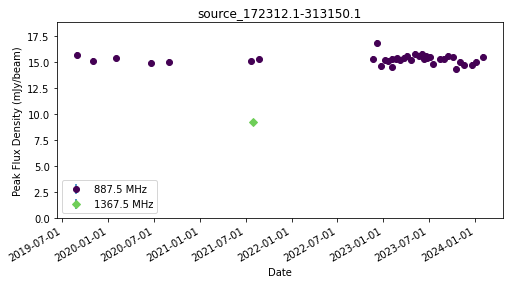

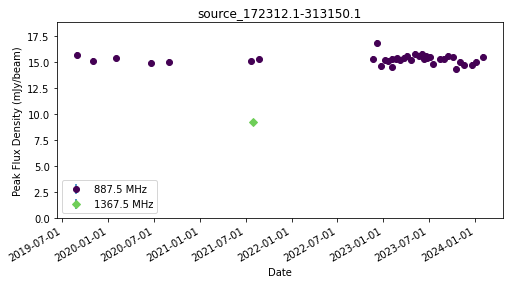

In [32]:
query.results[0].plot_lightcurve()